# Diabetes Dataset — Exploratory Data Analysis

This notebook performs exploratory data analysis (EDA) on the Pima Indians
Diabetes dataset used in the Healytics project.

### Objectives

- Understand the distribution of the target variable
- Analyze numerical feature distributions
- Identify potential outliers
- Examine relationships between features
- Study relationships between features and diabetes outcome
- Generate insights that can guide model development

EDA is performed to understand the data before building machine learning models.

## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

The raw diabetes dataset is loaded from the project's `data/raw` directory.

The dataset contains 768 records, 8 input features, and 1 target variable.

In [3]:
df = pd.read_csv("../data/raw/diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
print("Dataset shape:", df.shape)

Dataset shape: (768, 9)


## 3. Dataset Overview

Before analyzing individual features, we inspect the data types and basic
statistical properties of the dataset.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Initial Observation

The dataset contains numerical features representing demographic and medical
measurements. The `Outcome` column is the binary target variable.

## 4. Target Variable Distribution

The `Outcome` variable represents the diabetes outcome:

- `0` → No diabetes
- `1` → Diabetes

The distribution of the target classes is examined to identify class imbalance.

In [7]:
print(df["Outcome"].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


In [8]:
print((df["Outcome"].value_counts(normalize=True) * 100).round(2))

Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64


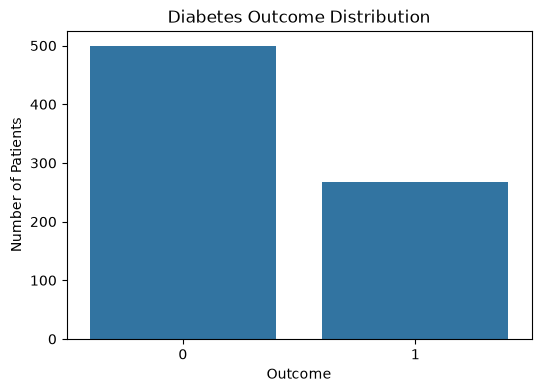

In [9]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Outcome")

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")

plt.show()

### Observation

The dataset contains more samples belonging to Outcome 0 than Outcome 1.
Therefore, the target variable is not perfectly balanced.

This should be considered during model evaluation. Accuracy alone should not
be used to assess model performance; precision, recall, F1-score, ROC-AUC, and
the confusion matrix should also be considered.

## 5. Distribution of Numerical Features

Histograms are used to understand the distribution of each numerical feature
and identify potentially skewed variables or unusual observations.

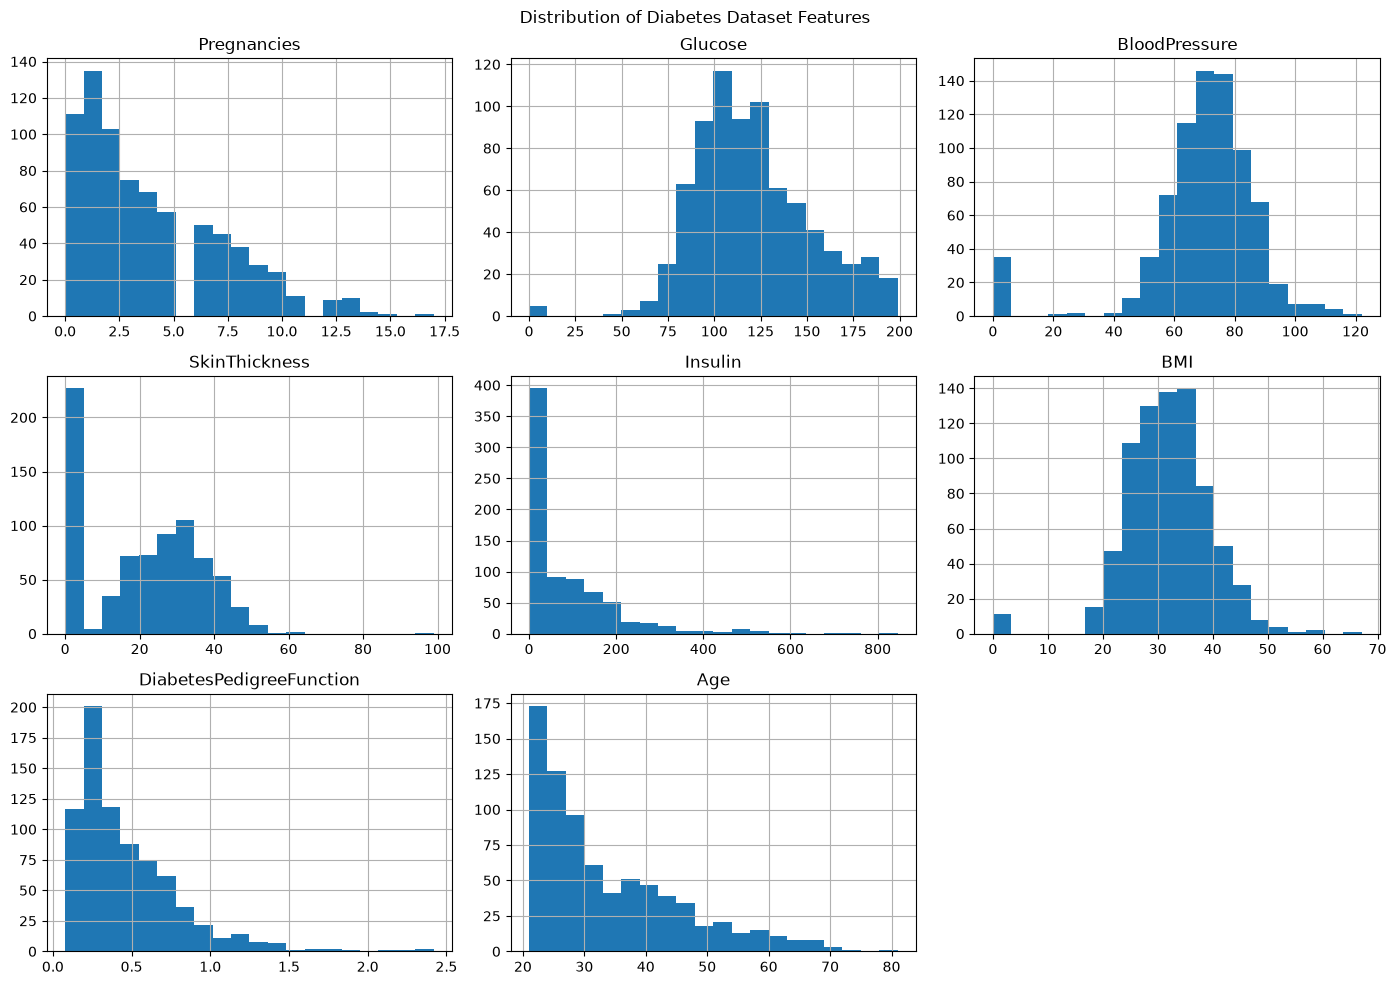

In [10]:
features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

df[features].hist(
    figsize=(14, 10),
    bins=20
)

plt.suptitle("Distribution of Diabetes Dataset Features")

plt.tight_layout()
plt.show()

## Observations from Feature Distributions

The histograms show that the numerical features have different distributions.

- `Pregnancies` is right-skewed, with most observations having relatively few pregnancies.
- `Glucose` shows a broad distribution with most observations concentrated in the middle range.
- `BloodPressure` is mainly concentrated around the middle range, with some unusual values.
- `SkinThickness` contains many zero-coded values in the raw dataset.
- `Insulin` is strongly right-skewed and contains many zero-coded values in the raw dataset.
- `BMI` is mainly concentrated in the middle range, with a small number of unusual values.
- `DiabetesPedigreeFunction` is right-skewed, with most observations at lower values.
- `Age` is right-skewed, with fewer observations at higher ages.

These distributions indicate that several features may contain skewness and
potential outliers. Further analysis using boxplots and correlation analysis
will be performed before drawing conclusions about their impact on the target
variable.

## 6. Boxplots for Numerical Features

Boxplots are used to identify the spread of each feature and detect potential
outliers.

The raw dataset is used here to understand its original data characteristics.
Invalid zero-coded measurements were handled separately during preprocessing.

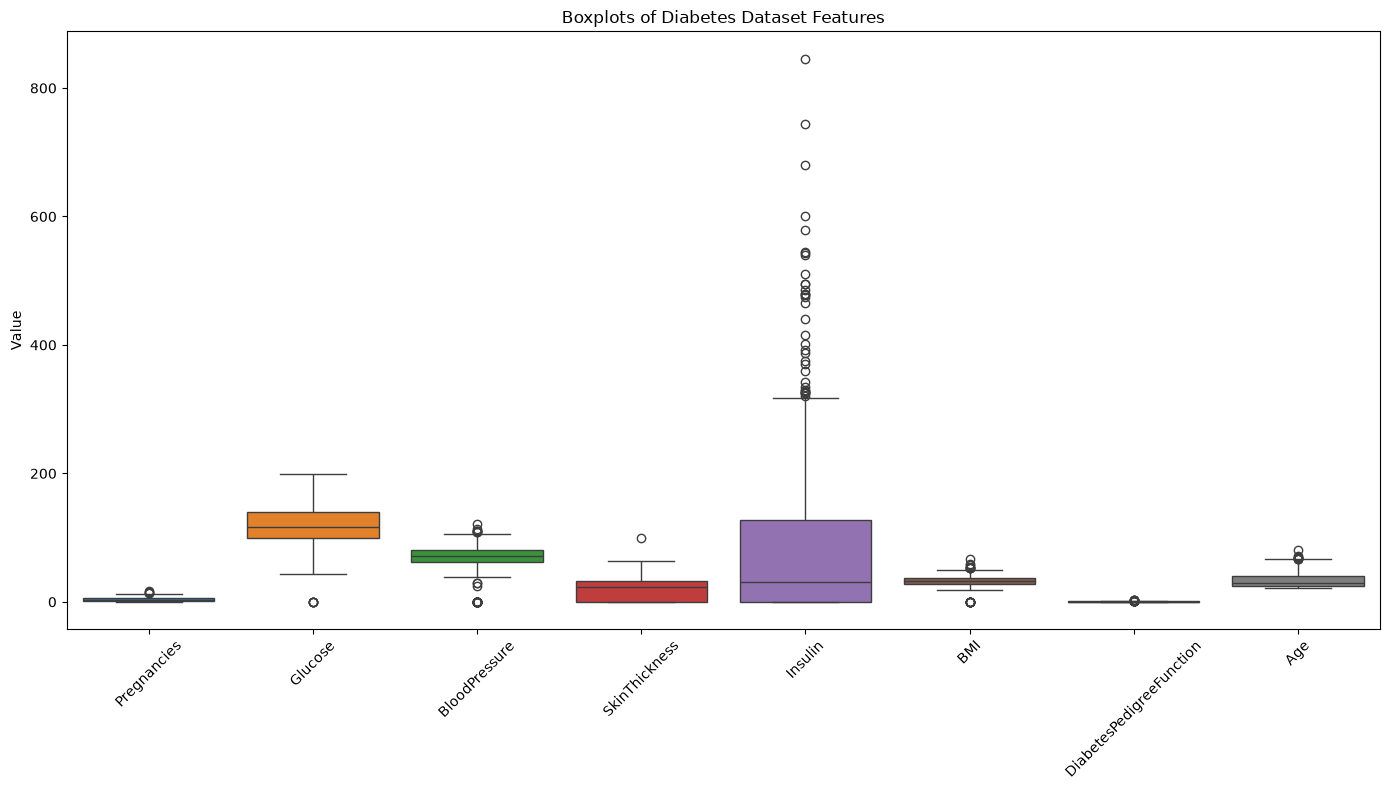

In [11]:
plt.figure(figsize=(14, 8))

sns.boxplot(data=df[features])

plt.title("Boxplots of Diabetes Dataset Features")
plt.xticks(rotation=45)
plt.ylabel("Value")

plt.tight_layout()
plt.show()

## Observations from Boxplots

The boxplots show that the numerical features have different ranges and
variability.

Several features contain observations outside the interquartile range (IQR),
indicating potential statistical outliers. `Insulin` shows a particularly
wide spread and a long upper tail.

The raw dataset also contains zero-coded missing measurements in features such
as `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI`. These values should
not automatically be classified as statistical outliers because they represent
missing measurements according to the dataset characteristics.

Potential outliers will therefore be investigated rather than automatically
removed.

## 7. Individual Feature Boxplots

Individual boxplots are used to examine the distribution and potential
outliers of each numerical feature more clearly.

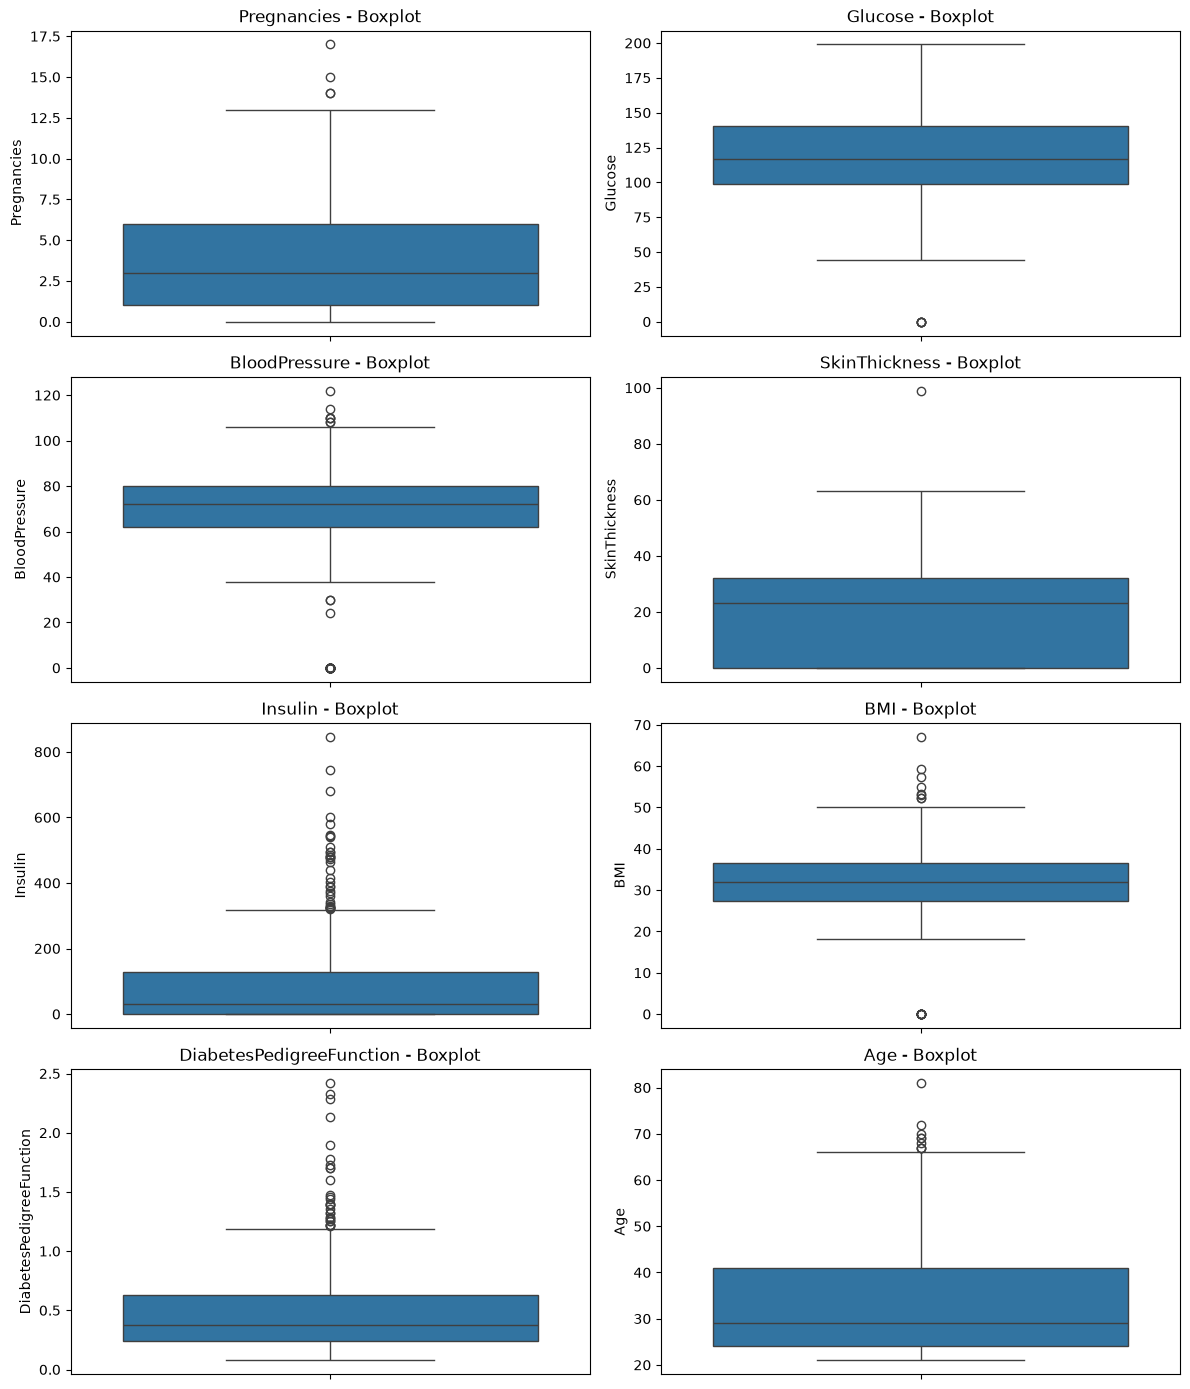

In [12]:
fig, axes = plt.subplots(4, 2, figsize=(12, 14))

for ax, feature in zip(axes.flat, features):
    sns.boxplot(y=df[feature], ax=ax)
    ax.set_title(f"{feature} - Boxplot")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

## 8. Correlation Analysis

Correlation analysis is used to examine the linear relationship between
numerical features in the diabetes dataset and to identify potentially
related features.

Pearson correlation coefficients range from -1 to +1:

- +1 → strong positive linear relationship
- 0 → little or no linear relationship
- -1 → strong negative linear relationship

Correlation does not imply causation.

The correlation matrix is used as an exploratory tool and will not by itself
determine which features are included in the final model.

In [13]:
correlation_matrix = df[features + ["Outcome"]].corr()

correlation_matrix

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


## 9. Correlation Heatmap

A heatmap provides a visual representation of the correlation matrix.
Darker or more intense values indicate stronger positive or negative
correlations.

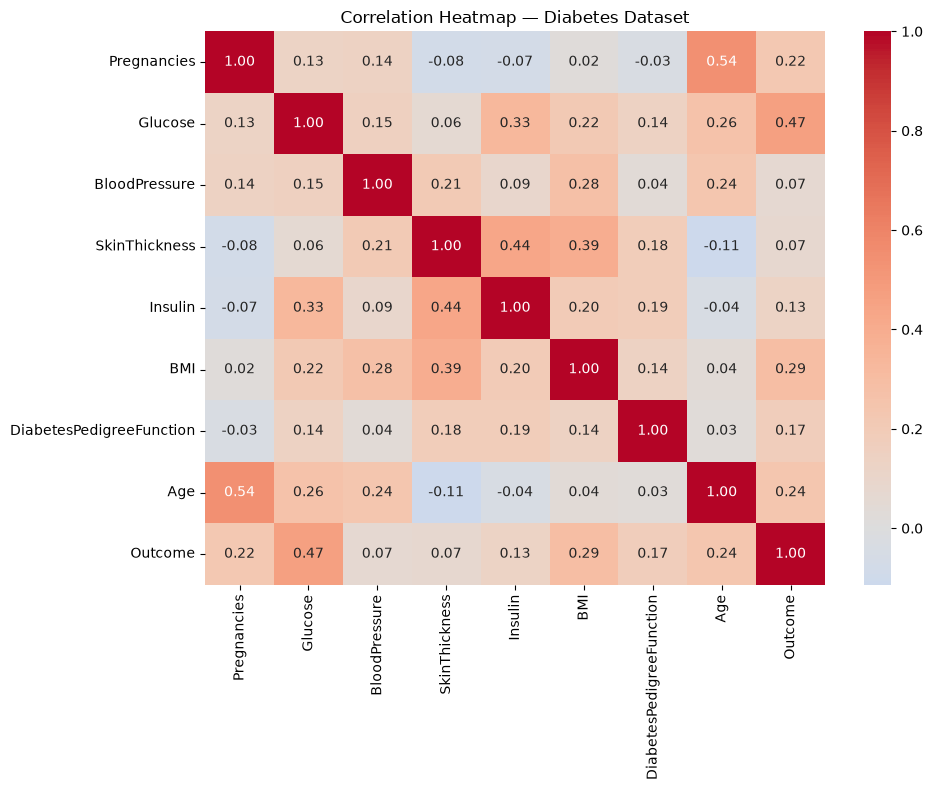

In [14]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap — Diabetes Dataset")
plt.tight_layout()
plt.show()

## Correlation Analysis — Observations

The correlation heatmap shows that `Glucose` has the strongest positive linear
correlation with the target `Outcome` among the features, with a correlation
coefficient of approximately 0.47.

Other features with positive correlations with `Outcome` include:

- `BMI` → 0.29
- `Age` → 0.24
- `Pregnancies` → 0.22
- `DiabetesPedigreeFunction` → 0.17
- `Insulin` → 0.13
- `BloodPressure` → 0.07
- `SkinThickness` → 0.07

Among the input features, `Pregnancies` and `Age` show a relatively stronger
positive correlation (0.54), while `SkinThickness` and `Insulin` show a
correlation of approximately 0.44.

These correlations describe linear associations in the dataset and do not
establish causation. The correlations should also be interpreted cautiously
because this heatmap is calculated from the raw dataset, which contains
zero-coded missing measurements.

## 10. Feature Distribution by Diabetes Outcome

The distributions of selected numerical features are compared across the two
target classes.

This helps visualize whether the feature distributions differ between
observations with Outcome 0 and Outcome 1.

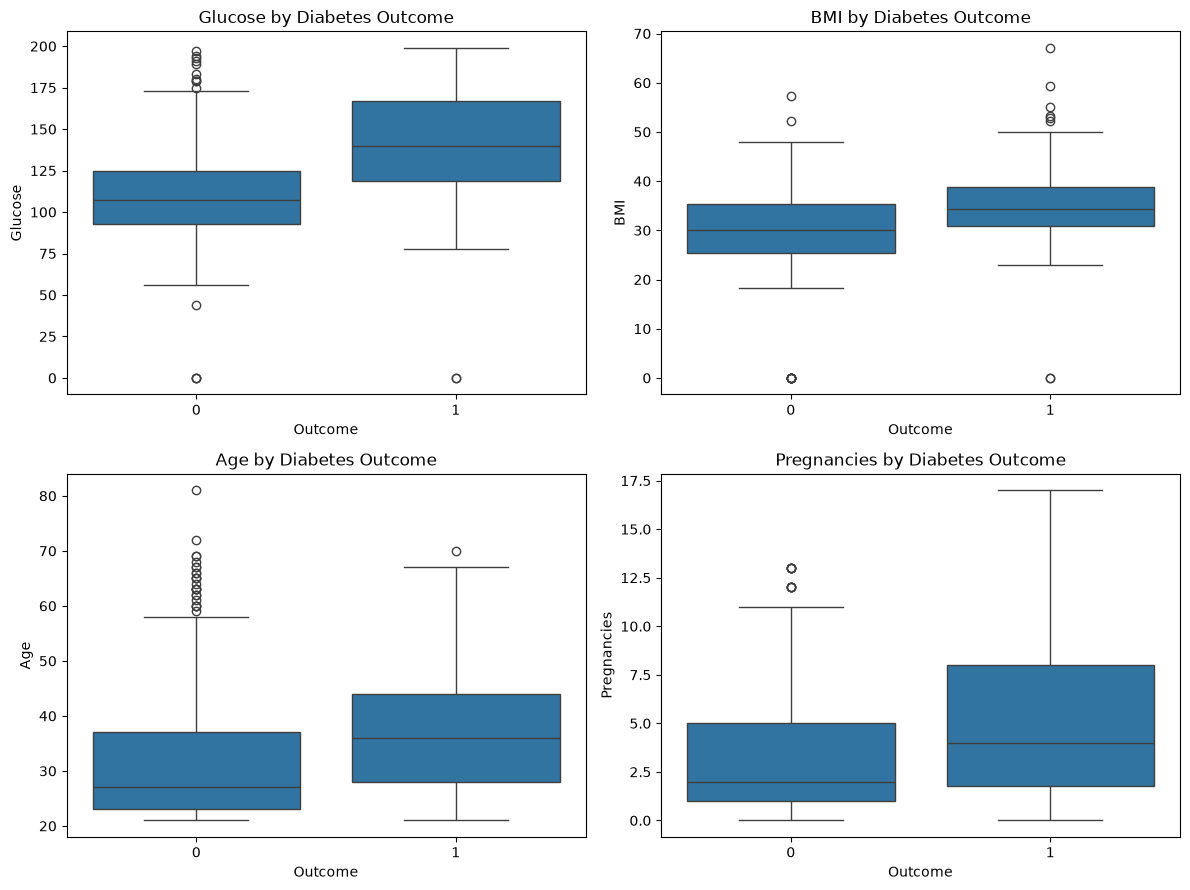

In [15]:
selected_features = [
    "Glucose",
    "BMI",
    "Age",
    "Pregnancies"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, feature in zip(axes.flat, selected_features):
    sns.boxplot(
        data=df,
        x="Outcome",
        y=feature,
        ax=ax
    )
    ax.set_title(f"{feature} by Diabetes Outcome")
    ax.set_xlabel("Outcome")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

## Observations — Feature vs Outcome

The boxplots show differences in the distributions of selected features between
Outcome 0 and Outcome 1.

- `Glucose` shows the most noticeable difference in median values between the
  two outcome groups.
- `BMI` has a higher median for Outcome 1, although substantial overlap exists.
- `Age` has a higher median for Outcome 1 compared with Outcome 0.
- `Pregnancies` also shows a higher median for Outcome 1.

The distributions overlap considerably for all four features, indicating that
no single feature can completely separate the two outcome classes.

The raw dataset also contains zero-coded measurements in some medical
features. These values should be treated according to the preprocessing
strategy rather than automatically interpreted as genuine measurements.

## 11. Additional Feature Analysis

The remaining numerical features are compared across the two diabetes outcome
classes to identify differences in their distributions.

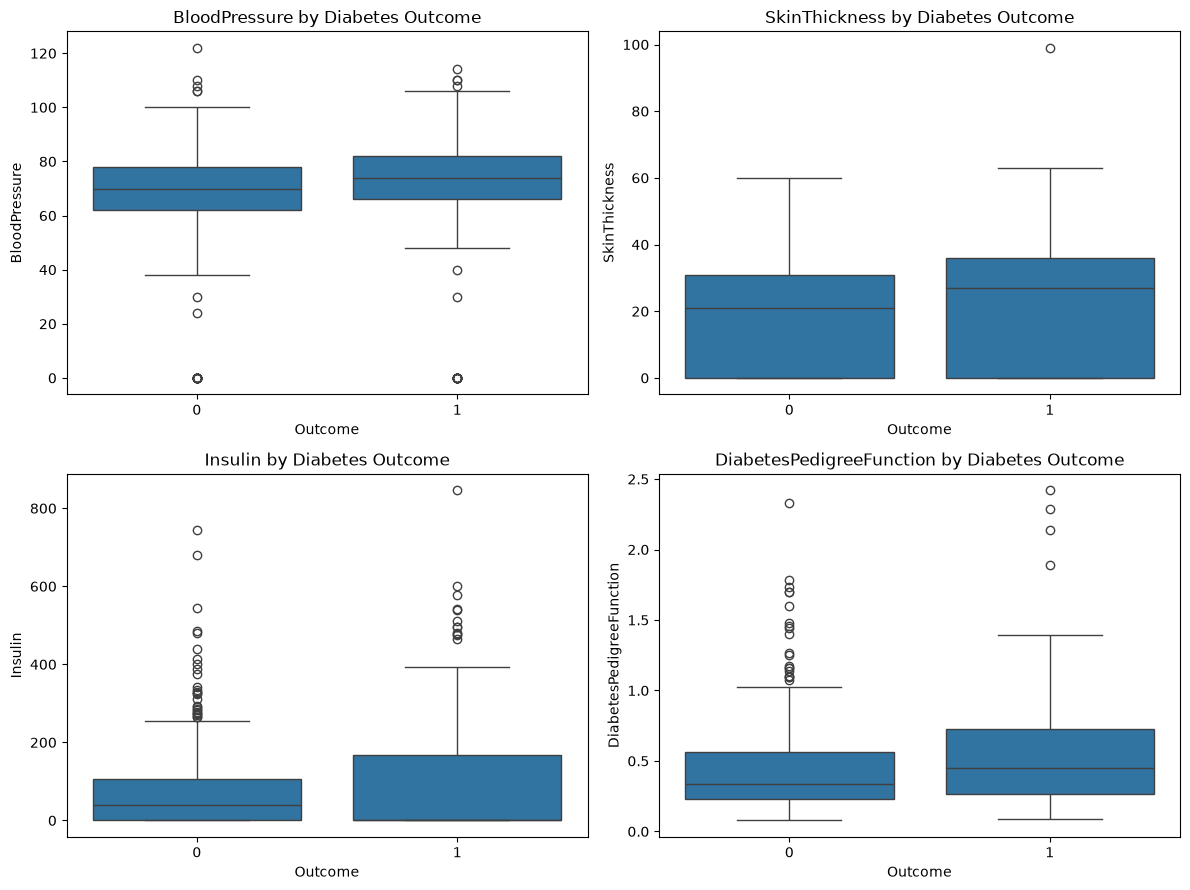

In [16]:
remaining_features = [
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "DiabetesPedigreeFunction"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, feature in zip(axes.flat, remaining_features):
    sns.boxplot(
        data=df,
        x="Outcome",
        y=feature,
        ax=ax
    )
    ax.set_title(f"{feature} by Diabetes Outcome")
    ax.set_xlabel("Outcome")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

## Observations — Additional Feature Analysis

The remaining features also show differences between the two outcome classes,
although considerable overlap exists.

- `BloodPressure` shows a relatively small difference in median values between
  the two outcome groups.
- `SkinThickness` has a somewhat higher median for Outcome 1, but the
  distributions overlap substantially.
- `Insulin` shows a higher median and wider spread for Outcome 1. It is also
  strongly right-skewed and contains many potential statistical outliers.
- `DiabetesPedigreeFunction` shows a higher median for Outcome 1 and a
  right-skewed distribution.

Several zero-coded values are visible because this analysis uses the raw
dataset. These values represent missing measurements for the relevant medical
features and were handled separately in the preprocessing stage.

The observed differences do not imply that any individual feature can
independently determine diabetes outcome.

## 12. EDA Summary and Key Findings

The exploratory analysis provides the following observations:

### Target Variable

The dataset contains approximately 65.10% Outcome 0 observations and 34.90%
Outcome 1 observations, indicating class imbalance.

### Feature Distributions

Several features show skewed distributions, particularly `Insulin`,
`DiabetesPedigreeFunction`, `Age`, and `Pregnancies`.

### Potential Outliers

Boxplots identify potential statistical outliers in several features.
These observations are not automatically considered errors and will not be
removed solely on the basis of the boxplots.

### Correlation

`Glucose` has the strongest positive linear correlation with `Outcome`
among the input features, followed by `BMI`, `Age`, and `Pregnancies`.

### Feature vs. Outcome

The distributions of several features differ between Outcome 0 and Outcome 1.
The difference is most visually noticeable for `Glucose`, while BMI, Age,
Pregnancies, and DiabetesPedigreeFunction also show differences in their
distributions.

### Overall Conclusion

The dataset contains meaningful variation, class imbalance, skewed features,
potential outliers, and zero-coded missing measurements. These characteristics
should be considered during model development and evaluation.

EDA findings alone are not sufficient to determine the final model or the
importance of individual features. Model-based evaluation will be performed
during the model development stage.

In [17]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)